In [ ]:
rfm.to_csv('customer_rfm_analysis.csv', index=False)

print("RFM analysis saved successfully!")

RFM analysis saved successfully!


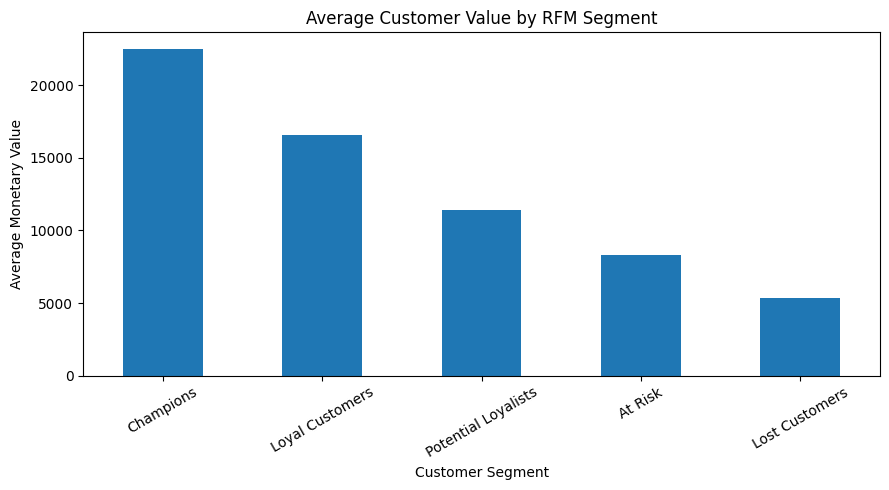

In [ ]:
plt.figure(figsize=(9, 5))

final_profile['Avg_Monetary'].plot(kind='bar')

plt.title('Average Customer Value by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
largest_segment = rfm['Segment'].value_counts().idxmax()
highest_churn_segment = segment_churn.idxmax()
highest_value_segment = final_profile['Avg_Monetary'].idxmax()

print("Overall Churn Rate:", round(churn_rate, 2), "%")
print("Largest Customer Segment:", largest_segment)
print("Highest Churn Segment:", highest_churn_segment)
print("Highest Average-Value Segment:", highest_value_segment)
print("Average Customer Frequency:", round(rfm['Frequency'].mean(), 2))
print("Average Customer Monetary Value:", round(rfm['Monetary'].mean(), 2))

Overall Churn Rate: 20.05 %
Largest Customer Segment: Potential Loyalists
Highest Churn Segment: Champions
Highest Average-Value Segment: Champions
Average Customer Frequency: 5.03
Average Customer Monetary Value: 13719.95


In [ ]:
final_profile = (
    rfm.groupby('Segment')
    .agg(
        Customers=('Customer ID', 'count'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .round(2)
)

# Sort by average monetary value
final_profile = final_profile.sort_values(
    by='Avg_Monetary',
    ascending=False
)

print(final_profile)

                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                                 
Champions                 9573        76.73           7.90      22509.13
Loyal Customers          13329       175.54           6.00      16574.61
Potential Loyalists      13367       240.03           4.31      11397.02
At Risk                   7110       370.70           3.26       8307.15
Lost Customers            6282       654.15           2.18       5338.36


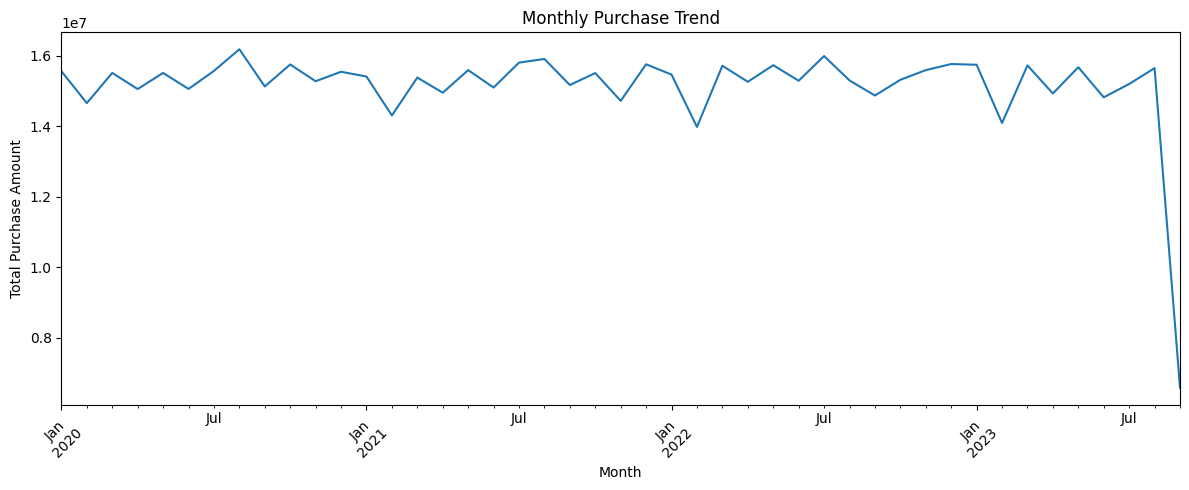

In [ ]:
plt.figure(figsize=(12, 5))

monthly_purchases.plot(kind='line')

plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_purchases = (
    df_clean.groupby('Purchase Month')['Total Purchase Amount']
    .sum()
)

print(monthly_purchases.head())

Purchase Month
2020-01    15566765
2020-02    14660710
2020-03    15517357
2020-04    15060419
2020-05    15517765
Freq: M, Name: Total Purchase Amount, dtype: int64


In [ ]:
# Make sure Purchase Date is in datetime format
df_clean['Purchase Date'] = pd.to_datetime(
    df_clean['Purchase Date'],
    errors='coerce'
)

# Create Purchase Month
df_clean['Purchase Month'] = df_clean['Purchase Date'].dt.to_period('M')

# Count unique customers per month
monthly_customers = (
    df_clean.groupby('Purchase Month')['Customer ID']
    .nunique()
)

print(monthly_customers.head())

Purchase Month
2020-01    5411
2020-02    5075
2020-03    5363
2020-04    5297
2020-05    5420
Freq: M, Name: Customer ID, dtype: int64


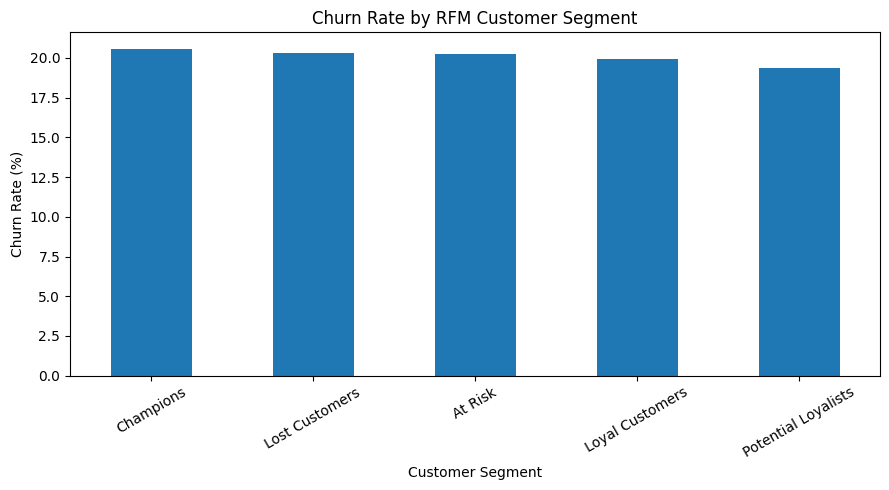

In [ ]:
import matplotlib.pyplot as plt

# Sort segments by churn rate
segment_churn_sorted = segment_churn.sort_values(ascending=False)

plt.figure(figsize=(9, 5))

segment_churn_sorted.plot(kind='bar')

plt.title('Churn Rate by RFM Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Remove old Churn column from rfm if the cell was already run
if 'Churn' in rfm.columns:
    rfm = rfm.drop(columns=['Churn'])

# Get churn status for each customer
customer_churn = (
    df_clean.groupby('Customer ID')['Churn']
    .max()
    .reset_index()
)

# Add churn information to RFM table
rfm = rfm.merge(
    customer_churn,
    on='Customer ID',
    how='left'
)

# Calculate churn rate by segment
segment_churn = (
    rfm.groupby('Segment')['Churn']
    .mean()
    .mul(100)
    .round(2)
)

print(segment_churn)

Segment
At Risk                20.24
Champions              20.58
Lost Customers         20.28
Loyal Customers        19.93
Potential Loyalists    19.37
Name: Churn, dtype: float64


In [ ]:
# Calculate overall churn rate
churn_rate = df_clean['Churn'].mean() * 100

print("Overall Churn Rate:", round(churn_rate, 2), "%")

Overall Churn Rate: 20.05 %


In [ ]:
rfm[rfm['Segment'] == 'Lost Customers'].sort_values(
    'Monetary',
    ascending=False
).head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
10600,10667,449,3,11344,1,1,2,4,Lost Customers
5154,5182,837,3,11329,1,1,2,4,Lost Customers
2884,2897,1015,3,11315,1,1,2,4,Lost Customers
9115,9167,771,3,11315,1,1,2,4,Lost Customers
7665,7714,696,3,11304,1,1,2,4,Lost Customers
24818,24975,678,3,11300,1,1,2,4,Lost Customers
16622,16733,529,3,11299,1,1,2,4,Lost Customers
28825,29011,760,3,11298,1,1,2,4,Lost Customers
20027,20156,583,3,11295,1,1,2,4,Lost Customers
28602,28785,781,3,11284,1,1,2,4,Lost Customers


In [ ]:
rfm[rfm['Segment'] == 'At Risk'].sort_values(
    'Monetary',
    ascending=False
).head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
6480,6519,754,3,15093,1,1,4,6,At Risk
13515,13601,480,3,14894,1,1,4,6,At Risk
16957,17070,449,4,14804,1,2,3,6,At Risk
37930,38184,506,4,14803,1,2,3,6,At Risk
11463,11534,269,3,14769,2,1,3,6,At Risk
10734,10801,491,4,14760,1,2,3,6,At Risk
46649,46967,908,3,14750,1,2,3,6,At Risk
11864,11941,550,3,14727,1,1,3,5,At Risk
31005,31205,528,4,14724,1,2,3,6,At Risk
37061,37306,643,4,14723,1,2,3,6,At Risk


In [ ]:
rfm.sort_values(
    ['RFM_Score', 'Monetary'],
    ascending=[False, False]
).head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
49406,49743,48,14,47015,5,5,5,15,Champions
22678,22821,16,12,46939,5,5,5,15,Champions
13717,13805,26,15,46567,5,5,5,15,Champions
13316,13400,14,14,46057,5,5,5,15,Champions
12568,12647,1,15,44562,5,5,5,15,Champions
35064,35294,21,15,44449,5,5,5,15,Champions
44211,44509,14,11,44087,5,5,5,15,Champions
835,842,9,13,43977,5,5,5,15,Champions
45023,45327,31,12,43875,5,5,5,15,Champions
43313,43606,8,13,43713,5,5,5,15,Champions


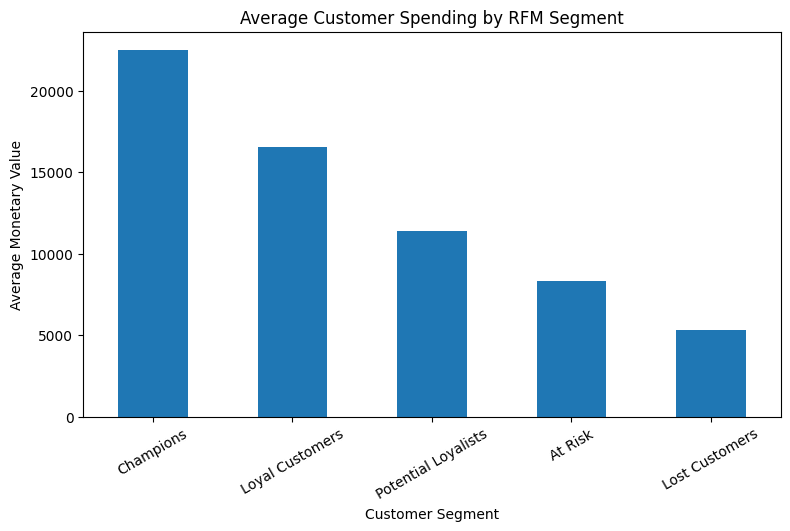

In [ ]:
plt.figure(figsize=(9,5))

segment_profile['Avg_Monetary'].plot(kind='bar')

plt.title('Average Customer Spending by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=30)
plt.show()

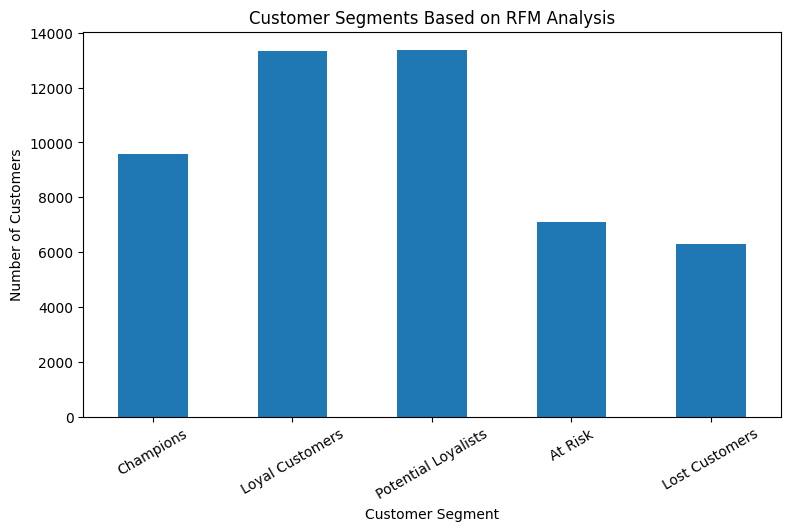

In [ ]:
segment_counts = rfm['Segment'].value_counts().reindex(segment_order)

plt.figure(figsize=(9,5))

segment_counts.plot(kind='bar')

plt.title('Customer Segments Based on RFM Analysis')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

In [ ]:
segment_order = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'At Risk',
    'Lost Customers'
]

segment_profile = segment_profile.reindex(segment_order)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Champions,9573,76.73,7.90,22509.13
Loyal Customers,13329,175.54,6.00,16574.61
Potential Loyalists,13367,240.03,4.31,11397.02
At Risk,7110,370.70,3.26,8307.15
Lost Customers,6282,654.15,2.18,5338.36


In [ ]:
segment_profile = rfm.groupby('Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,7110,370.70,3.26,8307.15
Champions,9573,76.73,7.90,22509.13
Lost Customers,6282,654.15,2.18,5338.36
Loyal Customers,13329,175.54,6.00,16574.61
Potential Loyalists,13367,240.03,4.31,11397.02


In [ ]:
segment_percentage = (
    rfm['Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

,proportion
Segment,
Potential Loyalists,26.92
Loyal Customers,26.84
Champions,19.28
At Risk,14.32
Lost Customers,12.65


In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Potential Loyalists,13367
Loyal Customers,13329
Champions,9573
At Risk,7110
Lost Customers,6282


In [ ]:
rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

In [ ]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

In [ ]:
rfm['RFM_Score'].value_counts().sort_index()

,count
RFM_Score,
3,3424
4,2858
5,3258
6,3852
7,4348
8,4453
9,4566
10,4431
11,4556


In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'] +
    rfm['F_Score'] +
    rfm['M_Score']
)

In [ ]:
rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score']].head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,1,289,3,6290,2,1,1
1,2,73,6,16481,4,4,4
2,3,223,4,9423,3,2,2
3,4,442,5,7826,1,3,2
4,5,425,5,9769,2,3,2
5,6,141,9,25428,3,5,5
6,7,142,8,17825,3,5,4
7,8,26,7,16245,5,4,4
8,9,141,7,24621,3,4,5
9,10,131,8,20672,4,5,5


In [ ]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [ ]:
print("Average Monetary Value:", rfm['Monetary'].mean())

Average Monetary Value: 13719.947222166287


In [ ]:
print("Average Frequency:", rfm['Frequency'].mean())

Average Frequency: 5.034131410966352


In [ ]:
print("Average Recency:", rfm['Recency'].mean())

Average Recency: 262.33537383459856


In [ ]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,49661.000000,49661.000000,49661.000000
mean,262.335374,5.034131,13719.947222
std,246.804539,2.199399,6811.065854
min,1.000000,1.000000,125.000000
25%,78.000000,3.000000,8718.000000
50%,187.000000,5.000000,13008.000000
75%,371.000000,6.000000,17921.000000
max,1352.000000,17.000000,50659.000000


In [ ]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,289,3,6290
1,2,73,6,16481
2,3,223,4,9423
3,4,442,5,7826
4,5,425,5,9769


In [ ]:
rfm = df_clean.groupby('Customer ID').agg(
    Recency=('Purchase Date', lambda x: (analysis_date - x.max()).days),
    Frequency=('Purchase Date', 'count'),
    Monetary=('Total Purchase Amount', 'sum')
).reset_index()

In [ ]:
analysis_date = df_clean['Purchase Date'].max() + pd.Timedelta(days=1)

analysis_date

Timestamp('2023-09-14 18:42:49')

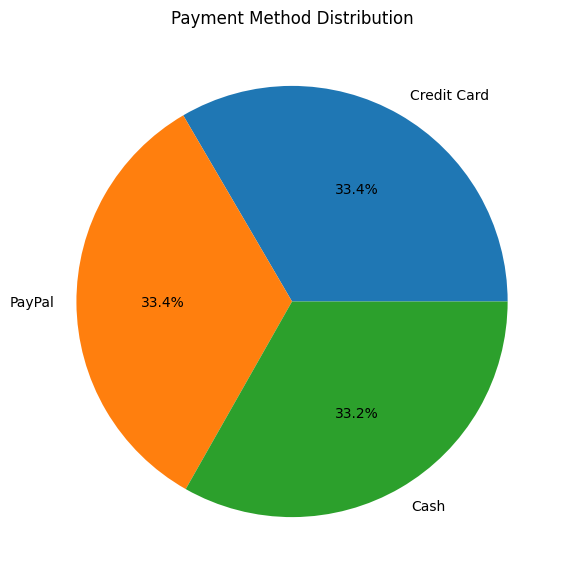

In [ ]:
payment_counts = df_clean['Payment Method'].value_counts()

plt.figure(figsize=(7,7))

payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

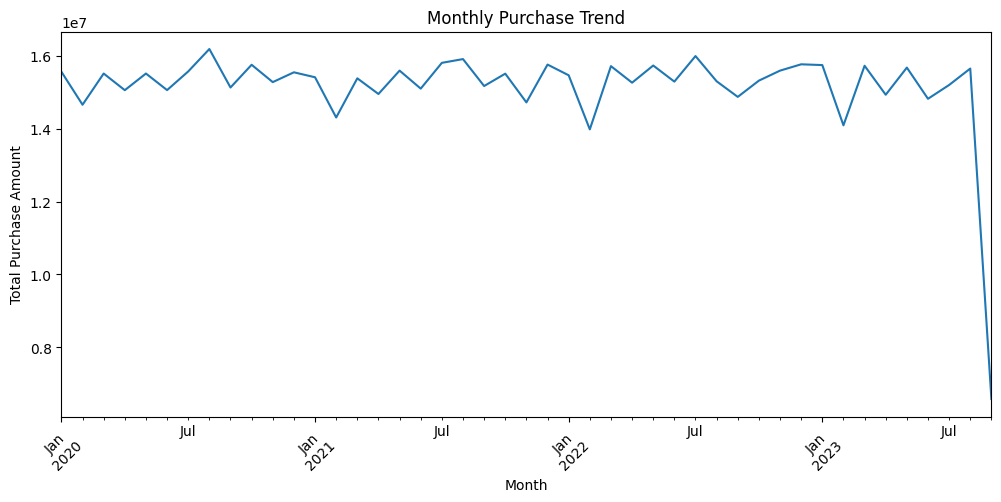

In [ ]:
monthly_sales = df_clean.groupby(
    df_clean['Purchase Date'].dt.to_period('M')
)['Total Purchase Amount'].sum()
plt.figure(figsize=(12,5))

monthly_sales.plot(kind='line')

plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=45)
plt.show()

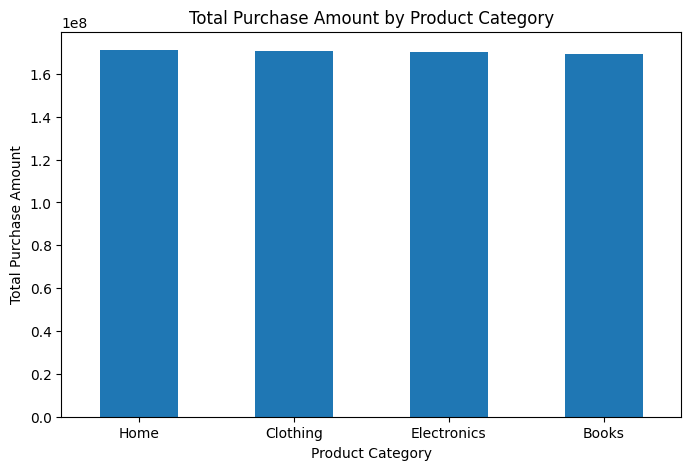

In [ ]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Total Purchase Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
avg_category_quantity = df_clean.groupby('Product Category')['Quantity'].mean().sort_values(ascending=False)

avg_category_quantity

,Quantity
Product Category,
Clothing,3.015100
Home,3.007211
Electronics,2.999537
Books,2.997863


In [ ]:
avg_category_purchase = df_clean.groupby('Product Category')['Total Purchase Amount'].mean().sort_values(ascending=False)

avg_category_purchase

,Total Purchase Amount
Product Category,
Home,2736.383806
Clothing,2727.922564
Books,2720.536508
Electronics,2716.685694


In [ ]:
payment_counts = df_clean['Payment Method'].value_counts()

payment_counts

,count
Payment Method,
Credit Card,83547
PayPal,83441
Cash,83012


In [ ]:
category_transactions = df_clean['Product Category'].value_counts()

category_transactions

,count
Product Category,
Electronics,62630
Clothing,62581
Home,62542
Books,62247


In [ ]:
category_sales = df_clean.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)

category_sales

,Total Purchase Amount
Product Category,
Home,171138916
Clothing,170716122
Electronics,170146025
Books,169345236


In [ ]:
df_clean.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Returns Status,Purchase Year,Purchase Month,Purchase Month Name,Purchase Day,Age Group
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0,Returned,2023,5,May,3,26-35
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0,Returned,2021,5,May,16,26-35
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0,Returned,2020,7,July,13,26-35
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0,No Return,2023,1,January,17,26-35
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0,Returned,2021,5,May,1,26-35


In [ ]:
df_clean['Age Group'].value_counts().sort_index()

,count
Age Group,
18-25,38978
26-35,47614
36-45,46825
46-55,46494
56-65,46506
66+,23583


In [ ]:
df_clean['Age Group'] = pd.cut(
    df_clean['Customer Age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

In [ ]:
df_clean['Purchase Day'] = df_clean['Purchase Date'].dt.day

In [ ]:
df_clean['Purchase Month Name'] = df_clean['Purchase Date'].dt.month_name()

In [ ]:
df_clean['Purchase Month'] = df_clean['Purchase Date'].dt.month

In [ ]:
df_clean['Purchase Year'] = df_clean['Purchase Date'].dt.year

In [ ]:
df_clean.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [ ]:
df_clean['Returns Status'].value_counts()

,count
Returns Status,
Returned,101476
No Return,101142
Not Recorded,47382


In [ ]:
df_clean['Returns Status'] = df_clean['Returns'].map({
    0.0: 'No Return',
    1.0: 'Returned'
}).fillna('Not Recorded')

In [ ]:
df_clean = df.copy()

In [ ]:
df[df['Returns'].isnull()]['Payment Method'].value_counts()

,count
Payment Method,
Credit Card,16030
Cash,15722
PayPal,15630


In [ ]:
df[df['Returns'].isnull()]['Product Category'].value_counts()

,count
Product Category,
Electronics,11926
Books,11828
Clothing,11827
Home,11801


In [ ]:
df.groupby(df['Returns'].isnull())['Total Purchase Amount'].mean()

,Total Purchase Amount
Returns,
False,2725.817662
True,2723.535857


In [ ]:
df['Returns'].dropna().value_counts()

,count
Returns,
1.0,101476
0.0,101142


In [ ]:
df[df['Returns'].isnull()].head(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
6,13738,2023-07-25 05:17:24,Electronics,205,1,2773,Credit Card,27,NaN,Lauren Johnson,27,Female,0
8,13738,2021-12-21 03:29:05,Home,12,2,2175,Cash,27,NaN,Lauren Johnson,27,Female,0
10,33969,2023-02-28 19:58:23,Clothing,410,3,5018,Credit Card,27,NaN,Carol Allen,27,Male,0
21,42650,2022-01-26 12:50:30,Electronics,105,2,3721,Credit Card,20,NaN,Curtis Smith,20,Female,0
26,42650,2020-05-24 06:45:48,Electronics,307,3,973,PayPal,20,NaN,Curtis Smith,20,Female,0
39,19676,2021-03-23 17:36:30,Electronics,218,4,2866,PayPal,57,NaN,Linda Lee,57,Male,0
40,19917,2023-05-16 01:34:44,Clothing,392,3,1378,Credit Card,34,NaN,Joshua Davis,34,Male,1
41,19917,2021-10-27 16:25:14,Clothing,238,3,1760,Credit Card,34,NaN,Joshua Davis,34,Male,1
42,19917,2021-12-09 07:43:45,Books,174,5,4517,Credit Card,34,NaN,Joshua Davis,34,Male,1
43,19917,2022-10-18 22:58:32,Electronics,41,2,743,Cash,34,NaN,Joshua Davis,34,Male,1


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [ ]:
df['Returns'].value_counts(dropna=False)

,count
Returns,
1.0,101476
0.0,101142
NaN,47382


In [ ]:
df['Churn'].value_counts(dropna=False)

,count
Churn,
0,199870
1,50130


In [ ]:
df['Payment Method'].value_counts()

,count
Payment Method,
Credit Card,83547
PayPal,83441
Cash,83012


In [ ]:
df['Product Category'].value_counts()

,count
Product Category,
Electronics,62630
Clothing,62581
Home,62542
Books,62247


In [ ]:
print("First Purchase Date:", df['Purchase Date'].min())
print("Last Purchase Date:", df['Purchase Date'].max())

First Purchase Date: 2020-01-01 00:07:26
Last Purchase Date: 2023-09-13 18:42:49


In [ ]:
df['Purchase Date'].dtype

dtype('<M8[ns]')

In [ ]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [ ]:
df['Purchase Date'].head()

,Purchase Date
0,2023-05-03 21:30:02
1,2021-05-16 13:57:44
2,2020-07-13 06:16:57
3,2023-01-17 13:14:36
4,2021-05-01 11:29:27


In [ ]:
df.mode(numeric_only=True).iloc[0]

,0
Customer ID,48382.0
Product Price,290.0
Quantity,4.0
Total Purchase Amount,2533.0
Customer Age,47.0
Returns,1.0
Age,47.0
Churn,0.0


In [ ]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,1
Returns,34984
Customer Name,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184712 entries, 0 to 184711
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            184712 non-null  int64  
 1   Purchase Date          184712 non-null  object 
 2   Product Category       184712 non-null  object 
 3   Product Price          184712 non-null  int64  
 4   Quantity               184712 non-null  int64  
 5   Total Purchase Amount  184712 non-null  int64  
 6   Payment Method         184712 non-null  object 
 7   Customer Age           184711 non-null  float64
 8   Returns                149728 non-null  float64
 9   Customer Name          184711 non-null  object 
 10  Age                    184711 non-null  float64
 11  Gender                 184711 non-null  object 
 12  Churn                  184711 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 18.3+ MB


In [ ]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [ ]:
df.shape

(184712, 13)

In [ ]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31.0,1.0,John Rivera,31.0,Female,0.0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31.0,0.0,John Rivera,31.0,Female,0.0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0


In [ ]:
df = pd.read_csv("ecommerce_customer_data_large.csv")

In [ ]:
import pandas as pd